# Convolution with images

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/convolution_for_images.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-26*

Part of this notebook is adapted from <https://tonysyu.github.io/ipython-jupyter-widgets-an-image-convolution-demo.html>.

## Learning objectives

- Generalise 1-D convolution to 2-D: convolve an image with a small kernel and inspect the result.
- See how different 3×3 kernels (identity, averaging, horizontal/vertical edge detectors) reveal different features in the same image.
- Practice designing your own kernels by editing the cell at the bottom.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.ndimage import convolve
from skimage import data, filters

plt.rcParams["image.cmap"] = "gray"
plt.rcParams["image.interpolation"] = "none"


## Pick an image

Uncomment one of the lines below to choose a different test image from `skimage.data`. The default is the `brick` texture, which has strong horizontal and vertical structure that is useful for visualising edge-detection kernels.

In [2]:
# image = data.chelsea()[:, :, 1]
# image = data.rocket()[:, :, -1]
# image = data.camera()
# image = data.checkerboard()
# image = data.stereo_motorcycle()[0][:, :, 0]
image = data.brick()

image.shape


(512, 512)

Apply a small Gaussian smoothing first so the rest of the demo works on a slightly less noisy version of the image.

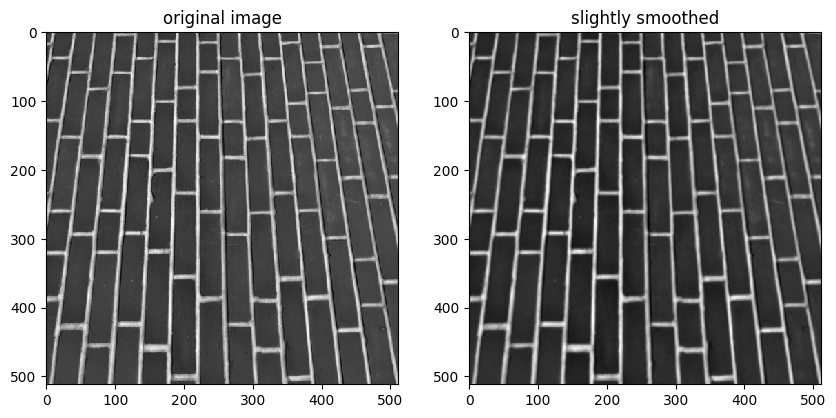

In [3]:
smooth_image = filters.gaussian(image, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image)
axes[0].set_title("original image")
axes[1].imshow(smooth_image)
axes[1].set_title("slightly smoothed")
plt.show()


## Helper: show kernel, original image, and convolved image side-by-side

In [4]:
def show_convolution(kernel, image):
    kernel = np.asarray(kernel)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    sns.heatmap(
        kernel,
        cmap=plt.cm.RdBu_r,
        annot=True,
        center=0,
        cbar=False,
        ax=axes[0],
    )
    axes[0].set_yticks([])
    axes[0].set_xticks([])
    axes[0].set_title("kernel")

    axes[1].imshow(image)
    axes[1].set_title("original image")

    response = convolve(image, kernel)
    axes[2].imshow(response)
    axes[2].set_title("convolved image")

    plt.show()
    return response


### Identity kernel

The 3×3 identity kernel passes the centre pixel through unchanged. Convolving with it returns the original image.

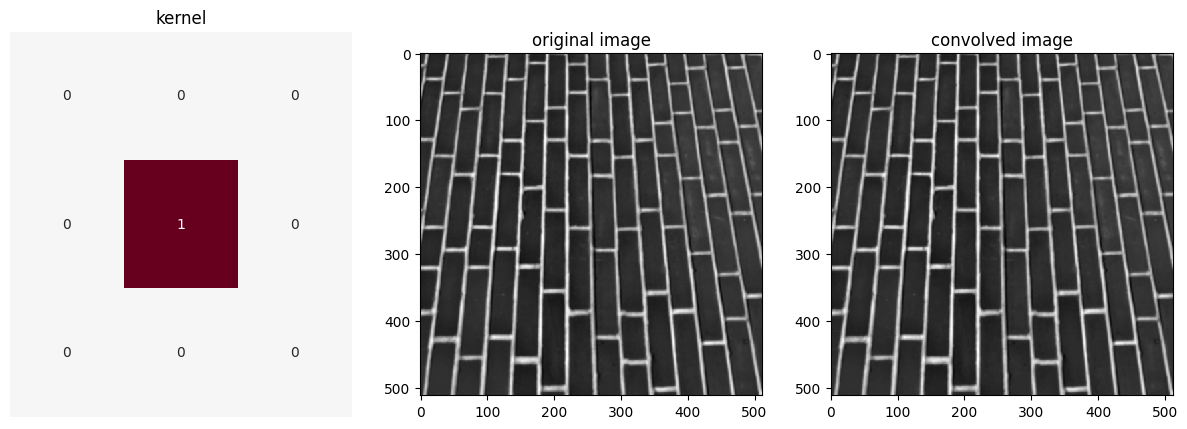

In [5]:
identity = [[0, 0, 0], [0, 1, 0], [0, 0, 0]]
_ = show_convolution(identity, smooth_image)


### Averaging kernel

All-ones gives an unnormalized box mean. The output is a brighter, smoother version of the input (try chaining multiple convolutions to smooth even more).

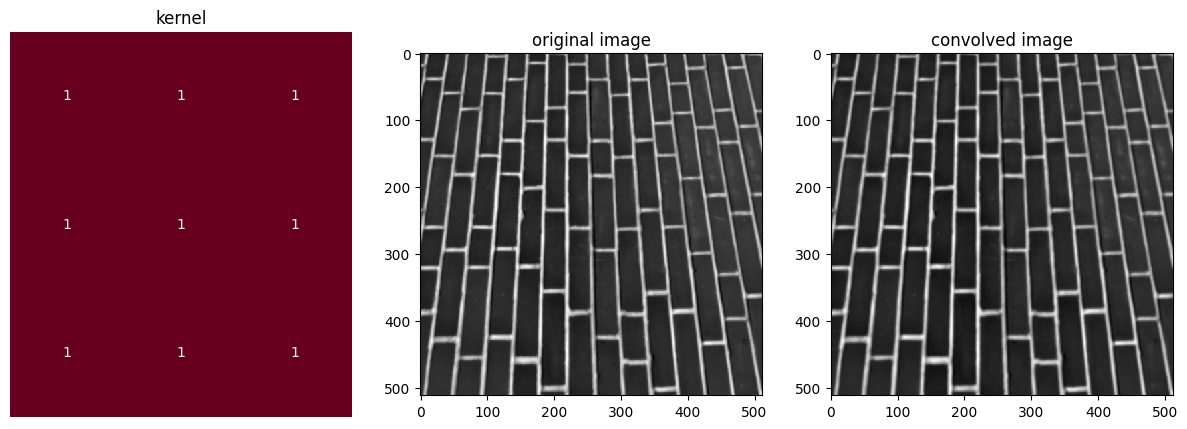

In [6]:
averaging = np.ones((3, 3))
_ = show_convolution(averaging, smooth_image)


### Horizontal-line detector

A centre row of $+2$ flanked by rows of $-1$ produces a strong response where the local image has bright horizontal stripes.

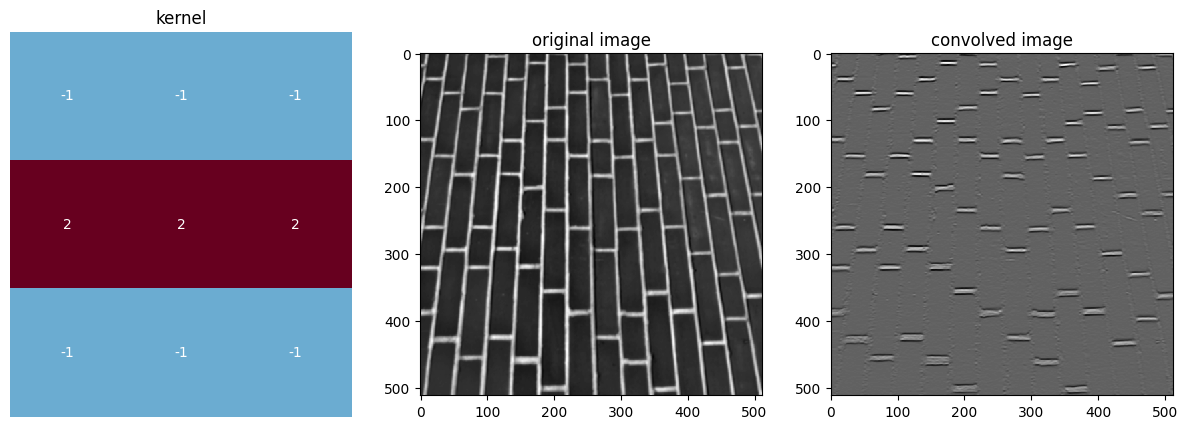

In [7]:
horizontal = [[-1, -1, -1], [2, 2, 2], [-1, -1, -1]]
_ = show_convolution(horizontal, smooth_image)


### Vertical-line detector

What do you think the vertical-line kernel looks like? It is just the transpose of the horizontal one.

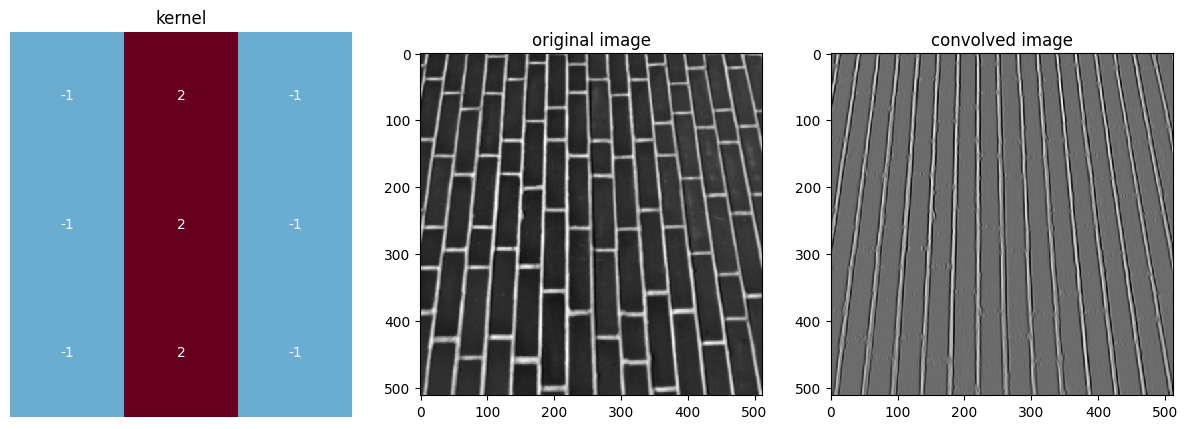

In [8]:
vertical = [[-1, 2, -1], [-1, 2, -1], [-1, 2, -1]]
_ = show_convolution(vertical, smooth_image)


---

## Your turn

Try out kernels from the resources below — for example, the Laplacian edge detector, sharpening kernels, or emboss kernels.

- <https://en.wikipedia.org/wiki/Kernel_(image_processing)>
- <https://aishack.in/tutorials/image-convolution-examples/>

If you want to go further, write your own unsharp-masking routine, or use the built-in `skimage.filters.unsharp_mask`:

- <https://scikit-image.org/docs/stable/auto_examples/filters/plot_unsharp_mask.html>

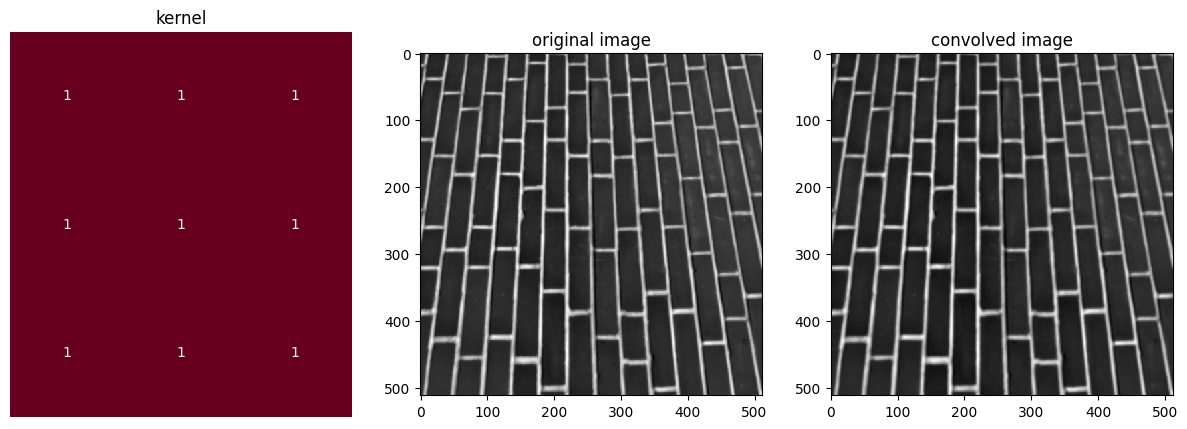

In [9]:
kernel = [[1, 1, 1], [1, 1, 1], [1, 1, 1]]
_ = show_convolution(kernel, smooth_image)


## Take-home point

A 2-D convolution is the same idea as a 1-D convolution: slide a kernel across the input, take a weighted sum at each location. The kernel pattern determines whether the operation smooths the image, sharpens it, or extracts specific oriented features. Edge detectors are kernels whose weights sum to zero — they amplify local *differences* rather than local averages.